# Types of Variables in Data

This notebook introduces the main types of variables used in data analysis and machine learning.

Main categories:
- **Categorical variables** (Nominal, Ordinal)
- **Numerical variables** (Discrete, Continuous, Interval, Ratio)


<img src="https://github.com/RogueRefiner/TU_UA/blob/main/Lecture_08/variable_types.png?raw=True" alt="My Image">


## 1. Categorical Variables
Variables that represent categories rather than numeric values in the mathematical sense.

### Nominal
- Categories **without a meaningful order**.
- Examples: countries, colors (purple, blue, red), car types.

### Ordinal
- Categories **with a natural order**, but the difference between values is not numerically meaningful.
- Unequal distances between two values.
- **No true zero point**.
- Examples: university grades, competition ranks (1st, 2nd, 3rd), age groups (0-20, 21-40, etc).

### 1.1 Binary Variables
Technically nominal but in practice a special type

#### Binary Variables
- Only two categories.
- Examples: yes/no, male/female, pass/fail.

## 2. Numerical Variables
Variables that represent measurable quantities.

### Discrete
- Countable, whole-number values.
- Examples: number of students, number of rainy days in a month, age.

### Continuous
- Can take any value within a range.
- Examples: height, temperature, time.

### 2.1. Further distinction for Continous Variables
Continous variables can be further split into `Interval` and `Ratio` variable types.  

### Interval
- **No true zero point**.
- Distance between two values is supposed to be equal.
- Example: temperature in °C, time of day, blood sugar level.

### Ratio
- Has a **true zero**.
- Each value can be compared to 0.
- Examples: height, distance, income, employment rate, elapsed time.

## 3. Why does this distinction matter? 

For preprocessing / encode our data to be useable in ML.
- Categorical → needs encoding (one-hot, ordinal encoding)
- Numerical → can be used directly
- Ratio/Interval → matters for scaling methods (min-max, standardization)
- Ordinal → must preserve ordering
- Nominal → ordering must NOT be introduced accidentally

## 4. Encoding techniques

### High-Cardinality Feature Encoding

When a categorical feature has a very large number of unique values (high cardinality). Encoding techniques like One-hot encoding become impractical due to a high dimensionality.
- **Binary Encoding**
- **Count/Frequency Encoding**
- **Hashing Encoding**
- **Leave-One-Out / Target Encoding**

### 4.1 Label Encoding

Assign each category a unique identifier. <br>
**Pros**: Simple & memory-efficient <br> 
**Contra**: Introduces implicit order which may be misinterpreted by non-tree models when used with nominal data.

In [31]:
from sklearn.preprocessing import LabelEncoder

colors = ["red", "blue", "green", "blue", "red"]

le = LabelEncoder()
encoded = le.fit_transform(colors)

encoded, le.classes_

(array([2, 0, 1, 0, 2]), array(['blue', 'green', 'red'], dtype='<U5'))

### 4.2 Ordinal encoding
Maps categories to integers, while maintaining the natural order <br>
**Pros**: Not suitable for nominal categories. <br>
**Contra**: Not suitable for nominal categories.

In [32]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

education = [["Bachelor"], ["Master"], ["PhD"], ["Master"]]

encoder = OrdinalEncoder(categories=[["Bachelor", "Master", "PhD"]])
encoded = encoder.fit_transform(education)

encoded


array([[0.],
       [1.],
       [2.],
       [1.]])

### 4.3 Binary Encoding
Represents categories as binary codes and splits them across multiple columns <br>
**Pros**: Reduces dimensionality, more memory-efficient than one-hot encoding. <br>
**Contra**: Slightly more complex; requires careful handling of missing values.

In [33]:
import category_encoders as ce
import pandas as pd

df = pd.DataFrame({"color": ["red", "blue", "green", "purple"]})

encoder = ce.BinaryEncoder(cols=["color"])
encoded = encoder.fit_transform(df)

encoded

,color_0,color_1,color_2
0,0,0,1
1,0,1,0
2,0,1,1
3,1,0,0


### 4.4 Count / Frequency Encoding
Assigns values to categories based on how often they occur in the dataset <br>
**Pros**: Low computational and storage requirements. <br>
**Contra**: Information might be used incorrectly if not handled properly. <br>

In [34]:
df = pd.DataFrame({"color": ["red", "blue", "red", "green", "blue"]})

counts = df["color"].value_counts()
df["color_count_encoded"] = df["color"].map(counts)

df

,color,color_count_encoded
0,red,2
1,blue,2
2,red,2
3,green,1
4,blue,2


### 4.5 Dictionary Encoding

In [35]:
age_group = ["young", "middle", "old", "young"]

mapping = {"young": 1, "middle": 2, "old": 3}

encoded = [mapping[x] for x in age_group]
encoded

[1, 2, 3, 1]

### 4.6 Cyclical Encooding

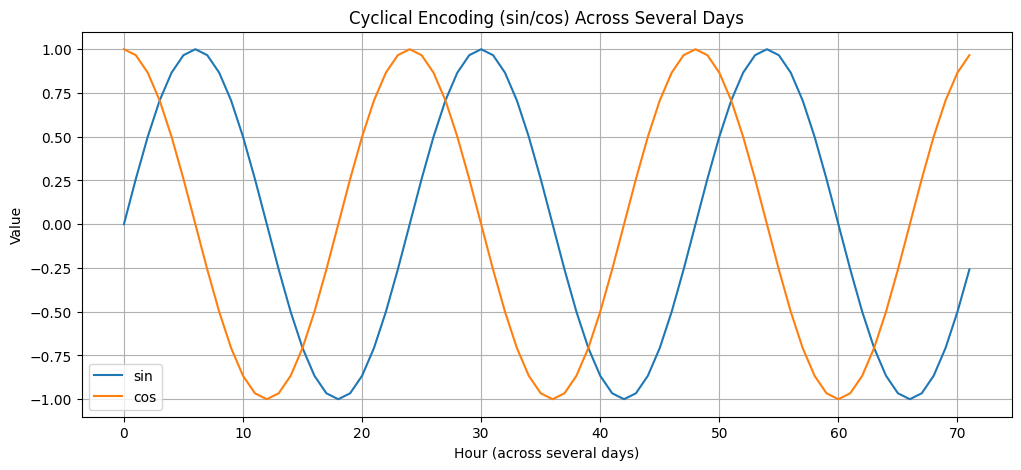

In [36]:
import numpy as np
import matplotlib.pyplot as plt
days = 3
hours = np.arange(24 * days)

sin_vals = np.sin(2 * np.pi * (hours % 24) / 24)
cos_vals = np.cos(2 * np.pi * (hours % 24) / 24)

plt.figure(figsize=(12, 5))

plt.plot(hours, sin_vals, label="sin")
plt.plot(hours, cos_vals, label="cos")

plt.xlabel("Hour (across several days)")
plt.ylabel("Value")
plt.title("Cyclical Encoding (sin/cos) Across Several Days")
plt.legend()
plt.grid(True)

plt.show()

### 4.7 Hash Encoding
Similar to One-hot encoding. But we don't get a column for each unique value. Hash Encoding gives us a lower dimensionality <br>
e.g. `red`, `blue`, `green`, `purple` would be one-hot encoded with 4 columns <br>
**Pros**: Efficient, Scalable, Low memory usage <br>
**Contra**: Hard to interpret, possible collisions <br>

In [37]:
df = pd.DataFrame({"color": ["red", "blue", "red", "green", "blue", "purple"]})

encoder = ce.HashingEncoder(cols=["color"], n_components=3)
encoded = encoder.fit_transform(df)

encoded

,col_0,col_1,col_2
0,0,1,0
1,1,0,0
2,0,1,0
3,0,0,1
4,1,0,0
5,0,1,0


In [38]:
# Example of a collision
df = pd.DataFrame({"color": ["red", "blue", "red", "green", "blue", "purple"]})

encoder = ce.HashingEncoder(cols=["color"], n_components=2)
encoded = encoder.fit_transform(df)

encoded

,col_0,col_1
0,1,0
1,0,1
2,1,0
3,1,0
4,0,1
5,0,1


### 4.8 Leave-one-out encoding / Target encoding
Leave-one-out encoding is a special type of target encoding <br>
Method that encodes each category in a categorical variable by calculating the mean of the target variable, while excluding the current data point <br>
**Pros**: Encoding is less affected by the current data point, retains relationship between each category and the target variable<br>
**Contra** Can introduce variability, especially when dealing with categories with a low number of data points (like our example), Computationally expensive, may introduce overfitting<br>

In [39]:
df = pd.DataFrame({
    "color": ["red", "blue", "red", "green", "blue", "purple", "purple", "purple"],
    "target": [1, 0, 1, 0, 0, 1, 0, 1]
})

encoder = ce.LeaveOneOutEncoder(cols=["color"])
encoded = encoder.fit_transform(df[["color"]], df["target"])

encoded

,color
0,1.0
1,0.0
2,1.0
3,0.5
4,0.0
5,0.5
6,1.0
7,0.5
